# Graph internal PII

- **Human** message stays in `state.messages` (original email).
- Each LLM node **appends** an **AI** message (raw JSON string) for the trace.
- Structured results live in **`pii_email`** and **`todo_list`** on `GlobalState`.
- TODO extraction runs in an **isolated subgraph** (`TODOState`: only `text` in); a **bridge** node maps `pii_email.text` → subgraph → `todo_list` + `messages` on `GlobalState`. Build cells need no `reducer_session`; invoke only inside `with reducer_session(...)`. The bridge forwards LangGraph `config` (e.g. `thread_id`) into the subgraph — details in `src/llm_nodes/todo_list/graph.py`.
- Parent Mermaid shows one `todo_list_node` box; optional second plot for the subgraph alone (`todo_graph.get_graph()`).
- `BaseReducerReader` only **observes** and vaults message copies — it does not redact.

Re-run graph + invoke cells after edits.

In [1]:
import sys

# See README.md - only valid for devcontainer workflow!
sys.path.insert(0, "/workspace")

from typing import Callable

from src.reducer.base_reader import BaseReducerReader

from langgraph.graph import END, START, StateGraph
from langchain_core.messages import HumanMessage

from IPython.display import Image, display
from src.llm_nodes.global_state import GlobalState
from src.reducer.reducer_session import reducer_session
from src.llm_nodes.pii_email.nodes import get_pii_email_node
from src.llm_nodes.todo_list.graph import build_todo_subgraph, make_todo_subgraph_runner


Example mail & model

In [2]:
MODEL = "ollama_chat/llama3.2:3b"

pii_email = """
This is a confidental email.

Task ulf.wendel@ phpdoc dot de to buy a cup of coffee,
and cto@ourcompany.com needs to reach out to all employees 
regarding the current coffee shortage as it is demotivating our technical staff.
Due date for both tasks is today.
"""

# email_domain_valid = ["ourcompany.com"]


In [3]:
# Isolated subgraph (TODOState) + bridge node for the parent graph
todo_graph = build_todo_subgraph(MODEL)
run_todo_subgraph = make_todo_subgraph_runner(todo_graph)

Parent graph (GlobalState)

`todo_list_node` is the bridge (`run_todo_subgraph`), not the raw subgraph.

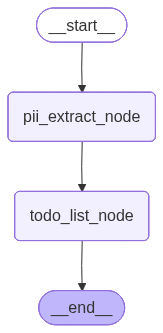

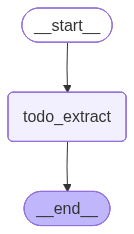

In [4]:
build_graph = StateGraph(GlobalState)

build_graph.add_node("pii_extract_node", get_pii_email_node(model=MODEL))
build_graph.add_node("todo_list_node", run_todo_subgraph)

build_graph.add_edge(START, "pii_extract_node")
build_graph.add_edge("pii_extract_node", "todo_list_node")
build_graph.add_edge("todo_list_node", END)

graph = build_graph.compile()

display(Image(graph.get_graph().draw_mermaid_png()))
display(Image(todo_graph.get_graph().draw_mermaid_png()))

Invoke

In [5]:
def make_reader(get_thread_id: Callable[[], str]):
    return BaseReducerReader(get_thread_id=get_thread_id)


reducer = None
with reducer_session("Chat-ABC", factory=make_reader) as session:

    print("")
    print("--- first turn ---")
    print("")

    reducer = session.reducer

    state = session.state(GlobalState, [HumanMessage(content=pii_email)])
    reply = await session.ainvoke(graph, state)

    state = GlobalState.model_validate(reply)
    for m in state.messages:
        if hasattr(m, "content") and isinstance(m.content, str):
            print(f"\tREPLY: {m.type}: {m.content}")

    print(f"\tPII: {state.pii_email}")
    print(f"\tTODO: {state.todo_list}")



--- first turn ---

REDUCER (thread=Chat-ABC): observing message content: 
This is a confidental email.

Task ulf.wendel@ phpdoc dot de to buy a cup of coffee,
and cto@ourcompany.com needs to reach out to all employees 
regarding the current coffee shortage as it is demotivating our technical staff.
Due date for both tasks is today.

REDUCER (thread=Chat-ABC): observing message content: {"text": "Task EMAIL0 to buy a cup of coffee, and EMAIL1 needs to reach out to all employees regarding the current coffee shortage as it is demotivating our technical staff.", "emails": ["ulf.wendel@ phpdoc dot de", "cto@ourcompany.com"]}
Task EMAIL0 to buy a cup of coffee, and EMAIL1 needs to reach out to all employees regarding the current coffee shortage as it is demotivating our technical staff.
REDUCER (thread=Chat-ABC): observing message content: {"items": [{"who": "EMAIL0", "what": "buy a cup of coffee"}, {"who": "EMAIL1", "what": "reach out to all employees", "when": "regarding the current coff

Vault

In [6]:

print("--- vault: your audit log  ---")
print("")
vault = reducer.get_vault_for_thread("Chat-ABC")
for k, v in vault.get():
    print(f"{k}: {v}")

reducer.reset_all()

--- vault: your audit log  ---

None: content='\nThis is a confidental email.\n\nTask ulf.wendel@ phpdoc dot de to buy a cup of coffee,\nand cto@ourcompany.com needs to reach out to all employees \nregarding the current coffee shortage as it is demotivating our technical staff.\nDue date for both tasks is today.\n' additional_kwargs={} response_metadata={}
None: content='{"text": "Task EMAIL0 to buy a cup of coffee, and EMAIL1 needs to reach out to all employees regarding the current coffee shortage as it is demotivating our technical staff.", "emails": ["ulf.wendel@ phpdoc dot de", "cto@ourcompany.com"]}' additional_kwargs={} response_metadata={} tool_calls=[] invalid_tool_calls=[]
None: content='{"items": [{"who": "EMAIL0", "what": "buy a cup of coffee"}, {"who": "EMAIL1", "what": "reach out to all employees", "when": "regarding the current coffee shortage"}]}' additional_kwargs={} response_metadata={} tool_calls=[] invalid_tool_calls=[]
1ca710ed-e9e4-460d-9f91-24079b9a9700: content=